In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Load the dataset (uploaded Excel file)
file_path = "Real estate valuation data set.xlsx" 
df = pd.read_excel(file_path, sheet_name='工作表1')

In [5]:
# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   No  X1 transaction date  X2 house age  \
0   1          2012.916667          32.0   
1   2          2012.916667          19.5   
2   3          2013.583333          13.3   
3   4          2013.500000          13.3   
4   5          2012.833333           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  Y house price of unit area  
0     24.98298     121.54024                        37.9  
1     24.98034     121.53951                        42.2  
2     24.98746     121.54391                        47.3  
3

In [7]:

# Display basic information about the dataset
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB
None


In [9]:

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


In [11]:
# Task 2: Basic Data Analysis
# Basic statistics
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
               No  X1 transaction date  X2 house age  \
count  414.000000           414.000000    414.000000   
mean   207.500000          2013.148953     17.712560   
std    119.655756             0.281995     11.392485   
min      1.000000          2012.666667      0.000000   
25%    104.250000          2012.916667      9.025000   
50%    207.500000          2013.166667     16.100000   
75%    310.750000          2013.416667     28.150000   
max    414.000000          2013.583333     43.800000   

       X3 distance to the nearest MRT station  \
count                              414.000000   
mean                              1083.885689   
std                               1262.109595   
min                                 23.382840   
25%                                289.324800   
50%                                492.231300   
75%                               1454.279000   
max                               6488.021000   

       X4 number of convenie

In [13]:
# Grouping: mean house price by number of convenience stores
grouped = df.groupby("X4 number of convenience stores")["Y house price of unit area"].mean().reset_index()
print("\nMean House Price per Unit Area by Convenience Store Count:")
print(grouped)


Mean House Price per Unit Area by Convenience Store Count:
    X4 number of convenience stores  Y house price of unit area
0                                 0                   26.462687
1                                 1                   31.839130
2                                 2                   31.412500
3                                 3                   29.536957
4                                 4                   37.474194
5                                 5                   44.729851
6                                 6                   46.951351
7                                 7                   43.848387
8                                 8                   44.696667
9                                 9                   51.732000
10                               10                   48.430000


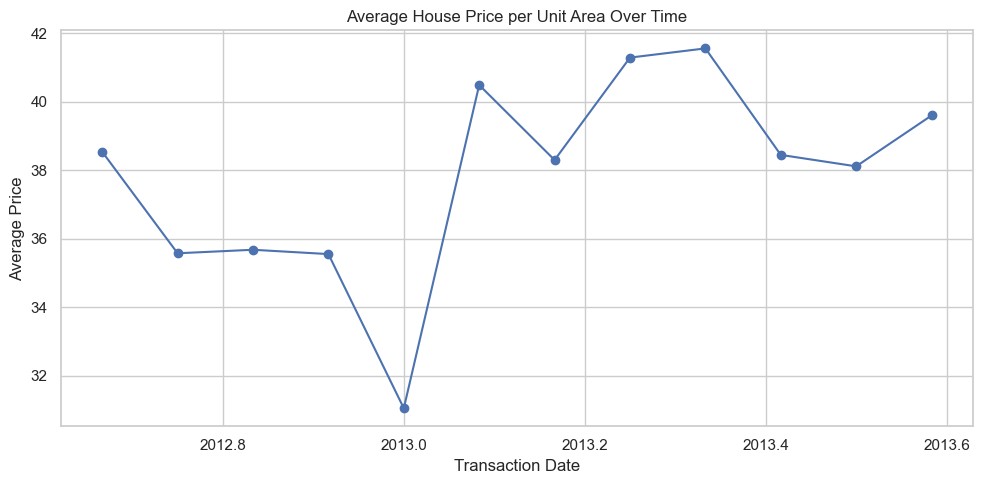

In [15]:
# Task 3: Data Visualization

# Set plot style
sns.set(style="whitegrid")

# 1. Line Chart - average house price over transaction dates
plt.figure(figsize=(10, 5))
avg_price_per_date = df.groupby("X1 transaction date")["Y house price of unit area"].mean()
avg_price_per_date.plot(marker='o')
plt.title("Average House Price per Unit Area Over Time")
plt.xlabel("Transaction Date")
plt.ylabel("Average Price")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\Shirley\AppData\Local\Temp\ipykernel_232\3400395277.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped, x="X4 number of convenience stores", y="Y house price of unit area", palette="viridis")


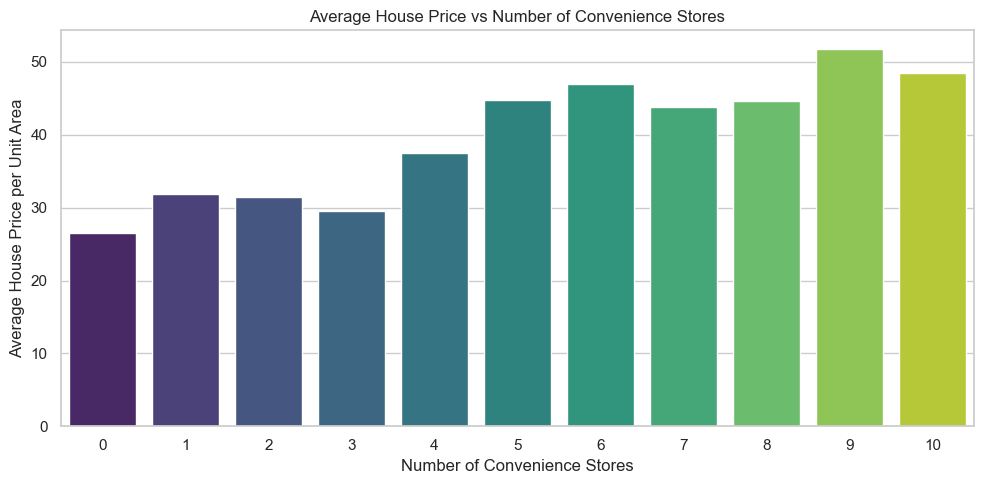

In [17]:
# 2. Bar Chart - average price by number of convenience stores
plt.figure(figsize=(10, 5))
sns.barplot(data=grouped, x="X4 number of convenience stores", y="Y house price of unit area", palette="viridis")
plt.title("Average House Price vs Number of Convenience Stores")
plt.xlabel("Number of Convenience Stores")
plt.ylabel("Average House Price per Unit Area")
plt.tight_layout()
plt.show()

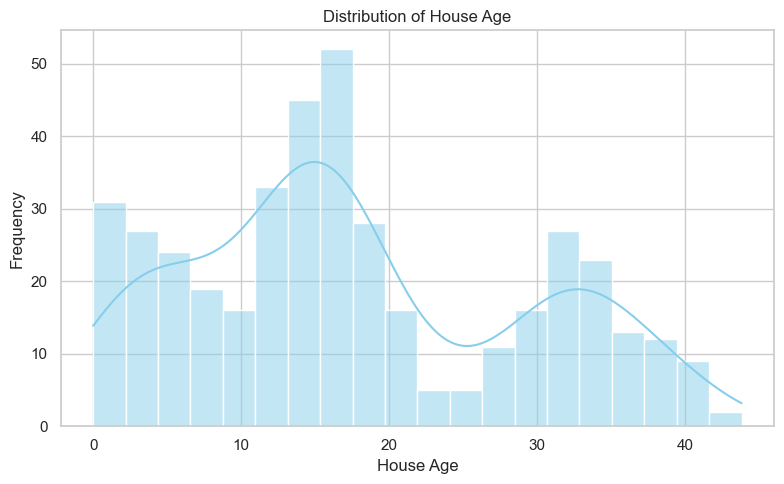

In [19]:
# 3. Histogram - distribution of house age
plt.figure(figsize=(8, 5))
sns.histplot(df["X2 house age"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of House Age")
plt.xlabel("House Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

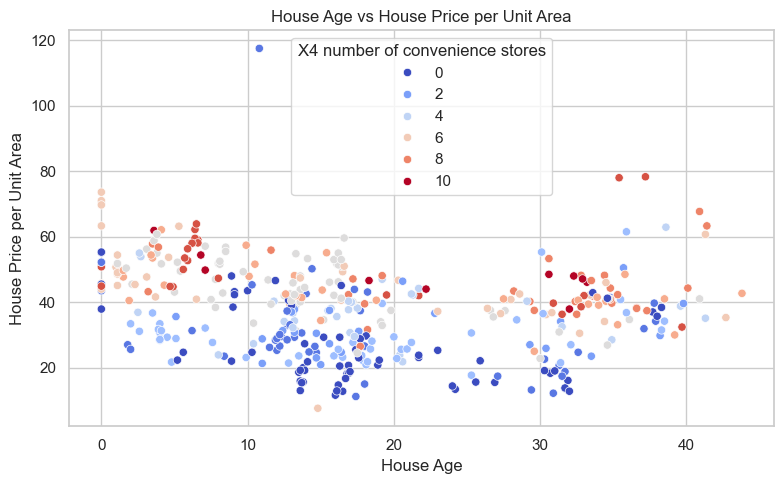

In [21]:
# 4. Scatter Plot - house age vs house price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="X2 house age", y="Y house price of unit area", hue="X4 number of convenience stores", palette="coolwarm")
plt.title("House Age vs House Price per Unit Area")
plt.xlabel("House Age")
plt.ylabel("House Price per Unit Area")
plt.tight_layout()
plt.show()